# Carbon Calculations for Emmission and Sequestration - single- site 

This Notebook outlines the estimates for Carbon Emmissions and Sequestrations given for the LivingWales LCCS habitat types. these estimates have been assessed through literature review which can be accessed here: <insert link>. 
    
These estimates are a guideline only as sequestration and emmission are highly influenced by other environmental variables such as soil type or seasonality. Therefopre this is taken as an annual rate average. 
    
This notebook is in development and if you have any input please contact us at livingearthhub.org.
    
    
List of Subheadings for navigation:
- 1.
- 2.
- 3.
- 4. 
- 5. 
- 6. 
- 7. 



# 0. Upload Packages 

In [1]:
# Set up to import packages
import os
import sys

import datacube
import pandas as pd
import numpy as np
import geopandas as gpd

from datacube.utils.geometry import Geometry, CRS
from ipyleaflet import GeoData

import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sys.path.append("/code/wales_utils/data_cube_utilities")
from display_tools import map_geom, rgb
from wdc_datahandling import geopolygon_masking

# Import common notebook functions. Assumes the file 'notebook_functions.py' is in the same directory
# TODO: Could have this in a common location everyone can access (e.g., ~/resources ? )
import notebook_functions
import notebook_dropdowns

## 1. Area Selection 

In [2]:
get_type, get_shapefile, get_polygon, reset_button = notebook_dropdowns.area_selection()
display(get_type)
display(get_shapefile)
display(get_polygon)
display(reset_button)

Dropdown(description='Type', options=('NRW forest legal boundaries', 'SSSI boundaries', 'drinking water catchm…

Dropdown(description='Vector', options=('nrw forest legal bound',), value='nrw forest legal bound')

Dropdown(description='Select a polygon', options=(), value=None)

Button(description='Reset', style=ButtonStyle())

### Check the site boundary visually and by area

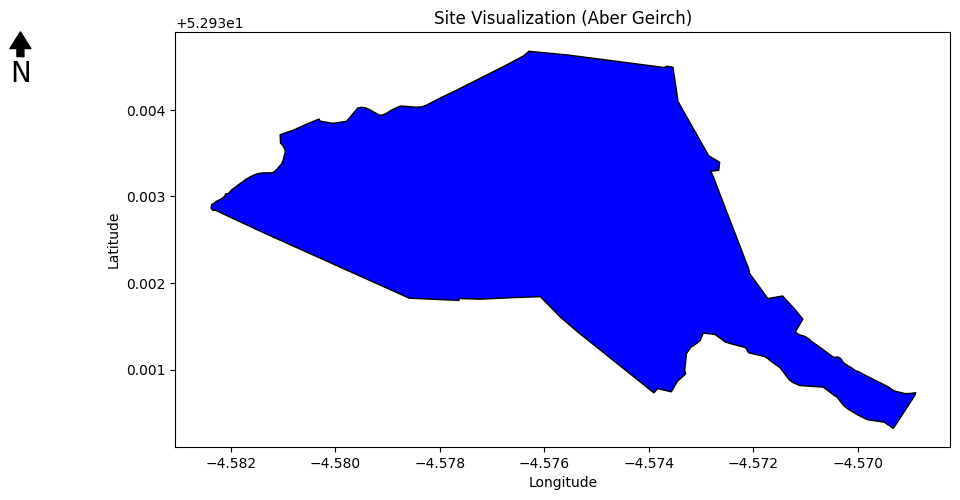

Total area: 50.49 ha


In [3]:
gpd_df_sub = notebook_dropdowns.static_polygon_plot(get_polygon)

### Visualise on a map and CONFIRM

In [4]:
notebook_dropdowns.interactive_polygon_plot(gpd_df_sub)

Map(center=[np.float64(52.93250289038324), np.float64(-4.575641922205672)], controls=(ZoomControl(options=['po…

In [5]:
# Transform shapefile boundaries into geographic data (and affect a style)
geo_data = GeoData(
    geo_dataframe=notebook_dropdowns.AREA_SELECTION.to_crs(epsg=4326),
    style={
        "color": "black",
        "fillColor": "#3366cc",
        "opacity": 0.05,
        "weight": 1.9,
        "dashArray": "2",
        "fillOpacity": 0.6,
    },
    hover_style={"fillColor": "red", "fillOpacity": 0.2},
    name="Boundary",
)

geom = Geometry(geom=notebook_dropdowns.AREA_SELECTION.to_crs(epsg=27700).iloc[0].geometry, crs=CRS("epsg:27700"))

## 2. Habitat map and Carbon tables

Living Wales habitat map for your area

In [6]:
year="2020"
query = {
    "geopolygon": geom,
    "time": (year + "-01-01", year + "-12-31"),
    "output_crs": "EPSG:27700",
    "resolution": (-10, 10),
    "dask_chunks": {"y": 2048, "x": 2048},
}

# Load habitat data for our polygon and time period
dc = datacube.Datacube()
habitat_dataset = dc.load(product="lw_habitats_lw", **query)
habitat_dataset_masked = geopolygon_masking(habitat_dataset, geopolygon=geom)

### 2.1 Habitat PLOT

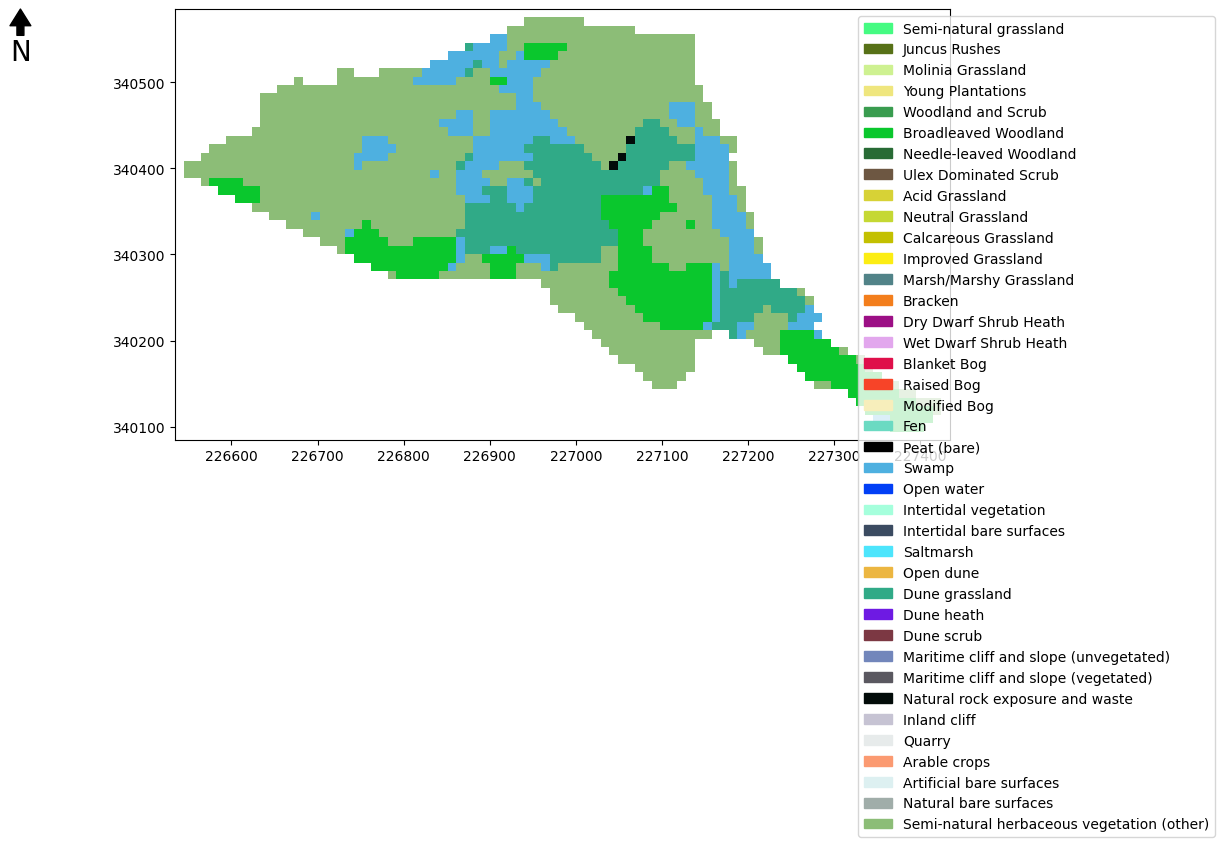

In [7]:
# Plotting
habitat_fig, ax =  plt.subplots(figsize=(10, 10))

habitat_plot = ax.imshow(
    habitat_dataset_masked.detailed.isel(time=0),
    cmap=notebook_functions.get_detailedhabitat_cmap(),
    norm=notebook_functions.get_detailedhabitat_norm(),
    extent=[
        habitat_dataset.x.min().data,
        habitat_dataset.x.max().data,
        habitat_dataset.y.min().data,
        habitat_dataset.y.max().data,
    ],
)

patches = [
    Patch(color=color, label=label[1]) for color, label in notebook_functions.detailedhabitat_scheme.items()
]

ax.legend(handles=patches, bbox_to_anchor=(1.35, 1), facecolor="white")

# Add north arrow
x, y = -0.2, 1  # Adjust these values based on your plot
arrow_length = 0.1
ax.annotate('N', xy=(x, y), xytext=(x, y - arrow_length),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=20,
            xycoords='axes fraction')

plt.show()

### 2.2 Habitats TABLE and Carbon Sequestration/Emmission values tables

In [10]:
habitat_stats_df = notebook_functions.stat_summary(habitat_dataset_masked.detailed, notebook_functions.detailedhabitat_scheme)
# Rename catergory to 'Habitat Type' to match 
habitat_stats_df = habitat_stats_df.rename(columns={"CATEGORY" : "Habitat Type"})

In [11]:
# Read in sequestration and emmision rates for habitats from CSV
# TODO: move this file to a shared location and use full path
carbon_data = pd.read_csv("Habitat_Carbon_Sequestration_and_Emission_Data.csv")

In [12]:
# Join tables to give carbon data for each habitat in the area
habitat_carbon_stats = pd.merge(habitat_stats_df, carbon_data, on="Habitat Type", how="left")

In [13]:
# Multiply rates per ha with areas of each habitat.
habitat_carbon_stats["Lowest Sequestration Rate (tC/yr)"] = habitat_carbon_stats["Lowest Sequestration Rate (tC/ha/yr)"] * habitat_carbon_stats["HECTARE"]
habitat_carbon_stats["Highest Sequestration Rate (tC/yr)"] = habitat_carbon_stats["Highest Sequestration Rate (tC/ha/yr)"] * habitat_carbon_stats["HECTARE"]
habitat_carbon_stats["Lowest Emission Rate (tC/yr)"] = habitat_carbon_stats["Lowest Emission Rate (tC/ha/yr)"] * habitat_carbon_stats["HECTARE"]
habitat_carbon_stats["Highest Emission Rate (tC/yr)"] = habitat_carbon_stats["Highest Emission Rate (tC/ha/yr)"] * habitat_carbon_stats["HECTARE"]

In [14]:
# Save out to a CSV for reading in excel and print table below
habitat_carbon_stats.to_csv(
    f"habitat_carbon_stats_{notebook_dropdowns.col_name_var}_{year}.csv", float_format="%.2f", index=False
)
habitat_carbon_stats

,Habitat Type,HECTARE,PERCENT,Lowest Sequestration Rate (tC/ha/yr),Highest Sequestration Rate (tC/ha/yr),Lowest Emission Rate (tC/ha/yr),Highest Emission Rate (tC/ha/yr),Lowest Sequestration Rate (tC/yr),Highest Sequestration Rate (tC/yr),Lowest Emission Rate (tC/yr),Highest Emission Rate (tC/yr)
0,Juncus Rushes,2.89,15.749319,-1.2,-3.0,0.0,3.0,-3.468,-8.670,0.0,8.670
1,Woodland and Scrub,2.56,13.950954,-1.0,-3.5,0.0,3.5,-2.560,-8.960,0.0,8.960
2,Broadleaved Woodland,2.68,14.604905,-2.0,-6.0,0.0,6.0,-5.360,-16.080,0.0,16.080
3,Needle-leaved Woodland,0.03,0.163488,-1.5,-4.0,0.0,4.0,-0.045,-0.120,0.0,0.120
4,Ulex Dominated Scrub,2.12,11.553134,-0.5,-2.0,0.0,2.0,-1.060,-4.240,0.0,4.240
5,Neutral Grassland,0.03,0.163488,-0.7,-2.0,0.0,2.0,-0.021,-0.060,0.0,0.060
6,Improved Grassland,4.19,22.833787,-1.5,-3.0,0.0,3.0,-6.285,-12.570,0.0,12.570
7,Marsh/Marshy Grassland,0.67,3.651226,-1.2,-3.5,0.0,3.5,-0.804,-2.345,0.0,2.345
8,Bracken,1.64,8.937330,-0.5,-1.5,0.0,1.5,-0.820,-2.460,0.0,2.460
9,Dry Dwarf Shrub Heath,0.02,0.108992,-0.2,-1.0,0.0,1.0,-0.004,-0.020,0.0,0.020


### 2.3 Habitats GRAPH 

(organise by greatest emmission to sequestration

In [ ]:
avg_emmision_rate = (habitat_carbon_stats["Lowest Emission Rate (tC/yr)"] + habitat_carbon_stats["Highest Emission Rate (tC/yr)"]) / 2
emission_lower_diff = habitat_carbon_stats["Lowest Emission Rate (tC/yr)"] - avg_emmision_rate
emission_upper_diff = habitat_carbon_stats["Highest Emission Rate (tC/yr)"] - avg_emmision_rate

In [ ]:
plt.bar(x=habitat_carbon_stats["Habitat Type"],
        height=habitat_carbon_stats["Highest Emission Rate (tC/yr)"],
        xerr=[emission_lower_diff, emission_upper_diff],
        label="Highest Emission Rate (tC/yr)")

### 2.4 Habitats STATISTICS

How much semi natural vs unnatural landscapes are there

## 3. Carbon emmissions 

Using the carbon emmisions table for LW Habitats

### 3.1 Emmissions PLOT x2 

Display heatmap of high vs low emmission habitats at the upper and lower range

### 3.2 Emissions TABLE

### 3.3 Emissions GRAPH

### 3.4 Emissions STATISTICS

## 4. Sequestration 

use carbon sequestration table 

### 4.1 Sequestration PLOT

Display heatmap of high vs low sequestration habitats at the upper and lower range

### 4.2 Sequestration TABLE

### 4.3 Sequestration GRAPH

### 4.4 Sequestration STATISTICS

## 5. The effect of Water  

To be added at a later date but attenuating the output to incllude the hydroperiod map 

### 5.1 Subheading PLOT

### 5.2 Subheading TABLE

### 5.3 Subheading GRAPH

### 5.4 Subheading STATISTICS